# 02 — Regression Models

Demonstrates the regression side of the ML Starter Kit: trying several regression models
through `get_model()`, comparing them with `compare_models()`, and visualizing how Ridge
and Lasso coefficients change with regularization strength using
`src.models.regularization`.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_data
from src.data.splitter import split_data
from src.preprocessing.pipeline import build_preprocessor, build_pipeline
from src.models.factory import get_model
from src.models.regularization import compute_regularization_path, DEFAULT_ALPHAS
from src.evaluation.metrics import evaluate_model
from src.evaluation.model_selection import compare_models
from src.utils.visualization import plot_residuals

## Load data and split

In [2]:
df = load_data("../data/raw/house_prices.csv")

# Rescale price into thousands -- keeps the target on a more numerically friendly scale for
# Lasso/ElasticNet's coordinate descent solver (avoids convergence warnings with default
# max_iter on a raw target in the hundreds-of-thousands range), and stays easy to interpret.
df["price"] = df["price"] / 1000

[07:09:37] INFO     src.data.loader: Loaded 'house_prices.csv' as csv -> shape=(500, 10)


DATA SUMMARY
Rows: 500   Columns: 10
Duplicate rows: 0

Dtypes:
float64    7
int64      2
object     1

Missing values: none


In [3]:
X_train, X_test, y_train, y_test = split_data(
    df.drop(columns=["house_id", "area_sqft_copy", "random_noise_1", "random_noise_2"]),
    target="price", test_size=0.25, random_state=42, stratify=False,  # regression -- no stratify
)
numerical_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

[07:09:37] INFO     src.data.splitter: Split data: train=(375, 5), test=(125, 5), stratified=False


Numerical: ['area_sqft', 'bedrooms', 'age_years', 'distance_to_city_km']
Categorical: ['locality']


## Compare several regression models

In [4]:
preprocessor = build_preprocessor(numerical_features, categorical_features)

comparison_df = compare_models(
    model_names=["linear", "ridge", "lasso", "elasticnet", "random_forest_regressor"],
    preprocessor=preprocessor,
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
    cv=5, scoring="r2", stratified=False,
)
comparison_df

[07:09:37] INFO     src.preprocessing.pipeline: Built preprocessor: 4 numeric, 1 categorical columns


[07:09:37] INFO     src.models.factory: Created model: linear -> LinearRegression({})


[07:09:37] INFO     src.evaluation.cross_validation: Cross-validation (5-fold, scoring=r2): mean=0.5770, std=0.0464


[07:09:37] INFO     src.evaluation.model_selection: compare_models -- linear: CV=0.5770, Test=0.5565


[07:09:37] INFO     src.models.factory: Created model: ridge -> Ridge({})


...

[07:09:37] INFO     src.evaluation.model_selection: compare_models -- elasticnet: CV=0.4288, Test=0.3931


[07:09:37] INFO     src.models.factory: Created model: random_forest_regressor -> RandomForestRegressor({})


[07:09:38] INFO     src.evaluation.cross_validation: Cross-validation (5-fold, scoring=r2): mean=0.6733, std=0.0608


[07:09:38] INFO     src.evaluation.model_selection: compare_models -- random_forest_regressor: CV=0.6733, Test=0.7222


,Model,CV Mean,CV Std,Test Score
0,random_forest_regressor,0.673295,0.060812,0.722228
1,ridge,0.577235,0.046449,0.556120
2,linear,0.577035,0.046446,0.556479
3,lasso,0.573998,0.048576,0.551207
4,elasticnet,0.428756,0.028342,0.393082


## Train the best model and evaluate

In [5]:
best_model_name = comparison_df.iloc[0]["Model"]
print(f"Best model by CV: {best_model_name}")

best_pipeline = build_pipeline(preprocessor, get_model(best_model_name))
best_pipeline.fit(X_train, y_train)

results = evaluate_model(best_pipeline, X_test, y_test, task="regression")
results

Best model by CV: random_forest_regressor
[07:09:38] INFO     src.models.factory: Created model: random_forest_regressor -> RandomForestRegressor({})


[07:09:38] INFO     src.evaluation.metrics: Evaluation (regression): {'MAE': 18.905288, 'MSE': 811.1058075600007, 'RMSE': 28.47991937418364, 'R2': 0.7274117967887701}


{'MAE': 18.905288,
 'MSE': 811.1058075600007,
 'RMSE': 28.47991937418364,
 'R2': 0.7274117967887701}

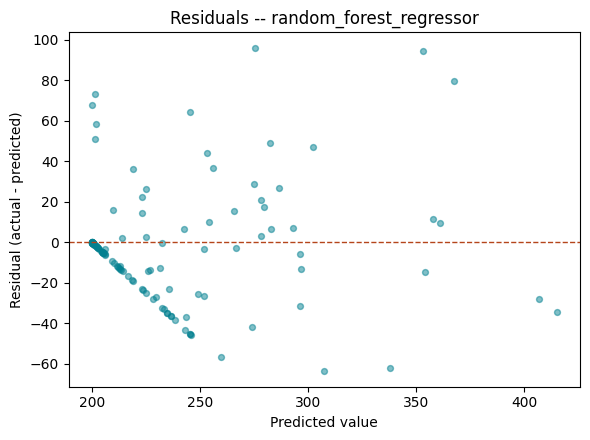

In [6]:
y_pred = best_pipeline.predict(X_test)
fig = plot_residuals(y_test, y_pred, title=f"Residuals -- {best_model_name}")
plt.show()

---
## Regularization path: how do Ridge and Lasso coefficients change with alpha?

We include the redundant/noise columns here on purpose -- `area_sqft_copy` (a near-duplicate
of `area_sqft`) and two pure noise columns -- so the path plot shows Lasso's feature-selection
behavior concretely.

In [7]:
from src.preprocessing.numerical import build_numeric_pipeline
import numpy as np

extended_features = ["area_sqft", "bedrooms", "age_years", "distance_to_city_km",
                      "area_sqft_copy", "random_noise_1", "random_noise_2"]
X_extended = df[extended_features]
y_extended = df["price"]

# Regularization paths need standardized features -- scale first (see this module's WHY note).
# IMPORTANT: the TARGET needs to be on a comparable scale too -- alpha's effective strength is
# relative to the target's variance, not just the features'. Skipping this causes the solver to
# barely regularize at all across a "reasonable-looking" alpha range (or fail to converge).
scaler_pipe = build_numeric_pipeline(imputation="median", scaling="standard")
X_scaled = scaler_pipe.fit_transform(X_extended)
y_scaled = (y_extended - y_extended.mean()) / y_extended.std()

# A tighter alpha range than the module's general-purpose DEFAULT_ALPHAS -- with BOTH X and y
# standardized, meaningful Lasso regularization for this dataset happens between roughly
# 1e-4 and 1, not up to 100 (that range would over-regularize almost everything to zero).
demo_alphas = np.logspace(-4, 0, 40)

alphas_lasso, coefs_lasso = compute_regularization_path(X_scaled, y_scaled, method="lasso", alphas=demo_alphas)
alphas_ridge, coefs_ridge = compute_regularization_path(X_scaled, y_scaled, method="ridge", alphas=demo_alphas)

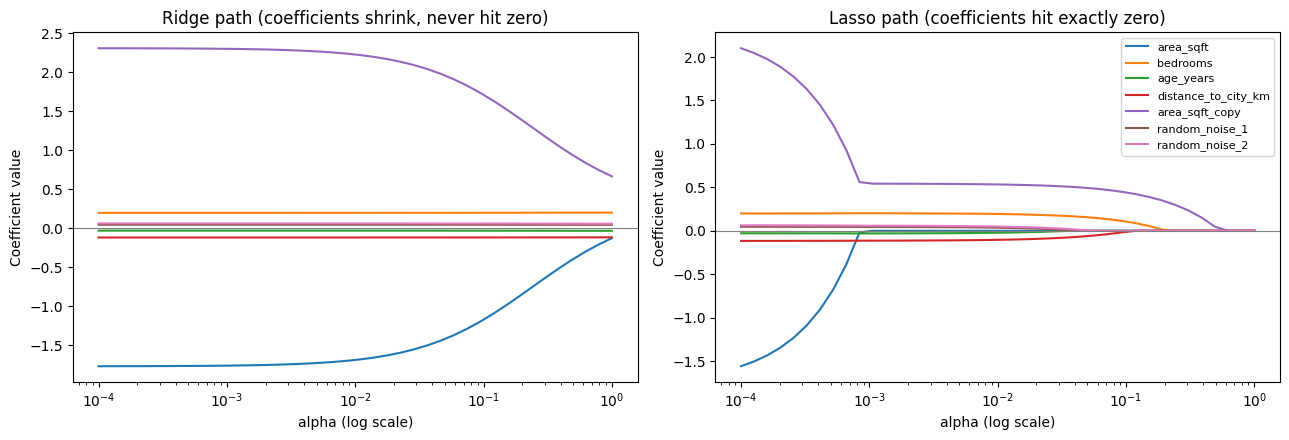

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for i, feat in enumerate(extended_features):
    axes[0].plot(alphas_ridge, coefs_ridge[i], label=feat)
    axes[1].plot(alphas_lasso, coefs_lasso[i], label=feat)

for ax, title in zip(axes, ["Ridge path (coefficients shrink, never hit zero)",
                              "Lasso path (coefficients hit exactly zero)"]):
    ax.set_xscale("log")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("Coefficient value")
    ax.set_title(title)
    ax.axhline(0, color="gray", linewidth=0.8)

axes[1].legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

**What to notice:** at the LEFT edge of each plot (small alpha, near-unregularized), notice
`area_sqft` and `area_sqft_copy` split a large coefficient between them unevenly rather than
sharing it evenly — this is the classic signature of two highly collinear features in a
lightly-regularized linear model (their sum still predicts price correctly, but individually
their split is unstable). As alpha increases (moving right), watch the Lasso panel: the noise
columns and one of the two duplicate columns get pushed toward zero, while Ridge (left panel)
shrinks every coefficient smoothly without ever fully reaching zero. This split-then-shrink
behavior with correlated features is a real, honest nuance beyond the simplest textbook
version of this story (no duplicate columns) — same underlying principle, slightly messier
data.